 # **1. Xử lý dữ liệu:**
 + Yêu cầu phải có file train và model chung trong một folder

In [1]:
!pip install tensorflow opencv-python matplotlib

In [ ]:
import tensorflow as tf
import os
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [4]:
data_dir = 'train'
os.listdir(data_dir)

['healthy', 'unhealthy', 'rubbish']

# in thử một số ảnh

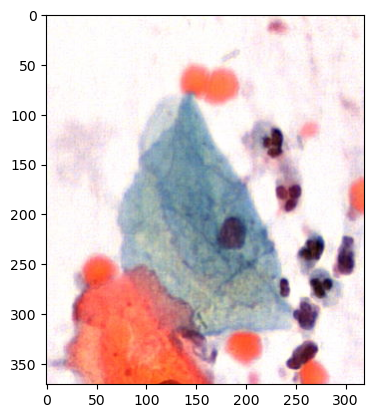

In [5]:
img = cv2.imread(os.path.join(data_dir,'healthy','image_10721.png'))
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))

In [165]:
data = tf.keras.utils.image_dataset_from_directory('train')
data = data.map(lambda x,y: (x/255, y))
data.as_numpy_iterator().next()[0].max()

Found 12609 files belonging to 3 classes.


1.0

Found 12609 files belonging to 3 classes.


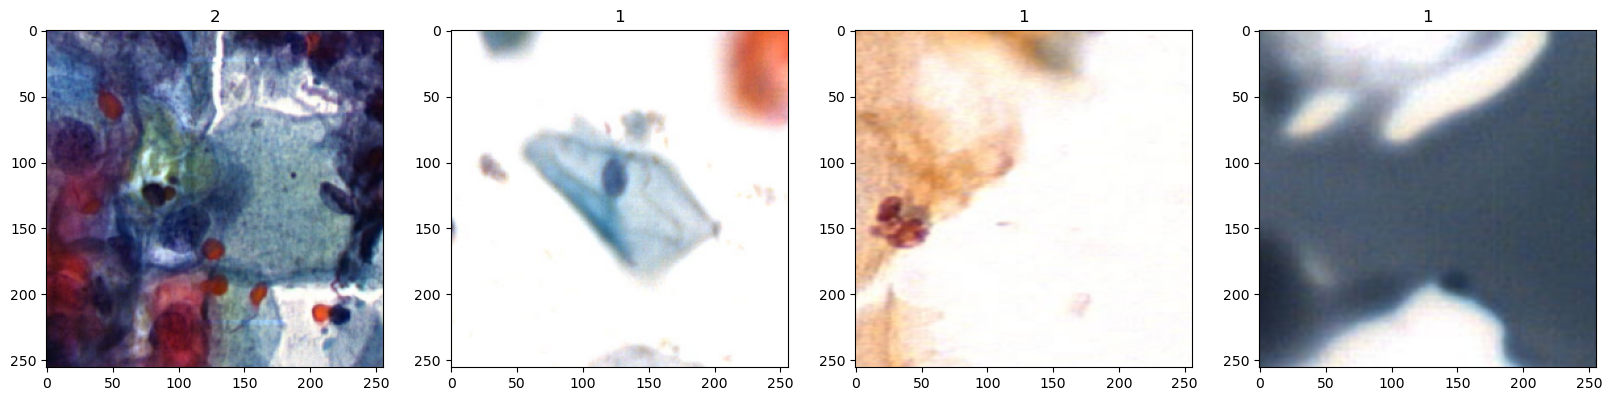

In [167]:
data = tf.keras.utils.image_dataset_from_directory('train')
data_iterator = data.as_numpy_iterator()
class_names = data.class_names
batch = data_iterator.next()
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))  
    ax[idx].title.set_text(batch[1][idx]) 

**Xử lý dữ liệu vì nhận thấy số lượng ảnh unhealthy và healthy thì quá ít, bằng cách OVERSAMPLING**
+ Thông qua việc xoay ảnh sau đó resize lại ảnh

In [3]:
import os
import shutil
import random
import cv2
import numpy as np
original_dataset_path = "train"
new_dataset_path = "augmented"
os.makedirs(new_dataset_path, exist_ok=True)
for class_name in ["healthy", "rubbish", "unhealthy"]:
    os.makedirs(os.path.join(new_dataset_path, class_name), exist_ok=True)
class_counts = {
    "healthy": 4278,
    "rubbish": 7462,
    "unhealthy": 862
}
target_count = 6000
def rotate_image(image, angle):
    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)
    matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(image, matrix, (w, h))
    return rotated

def resize_image(image, size=(256, 256)):
    return cv2.resize(image, size, interpolation=cv2.INTER_AREA)

def augment_and_save_images(class_name, current_count, target_count):
    class_dir = os.path.join(original_dataset_path, class_name)
    new_class_dir = os.path.join(new_dataset_path, class_name)
    images = [f for f in os.listdir(class_dir) if f.endswith(('.jpg', '.png'))]
    for img_name in images:
        shutil.copy(os.path.join(class_dir, img_name), new_class_dir)
    
    while current_count < target_count:
        img_name = random.choice(images)
        img_path = os.path.join(class_dir, img_name)
        image = cv2.imread(img_path)
        if image is None:
            continue
            
        angle = random.choice([90, 180, 270])
        rotated_image = rotate_image(image, angle)
        resized_image = resize_image(rotated_image)
        new_img_name = f"aug_{current_count}.jpg"
        cv2.imwrite(os.path.join(new_class_dir, new_img_name), resized_image)
        current_count += 1

for class_name, count in class_counts.items():
    augment_and_save_images(class_name, count, target_count)


# check dữ liệu sau khi đã thêm các ảnh

+ Nhận thấy các ảnh giờ đây có số lượng ~ 6000 ảnh cho mỗi nhãn 

In [4]:
class_names = ["healthy", "rubbish", "unhealthy"]
for class_name in class_names:
    class_path = os.path.join('augmented', class_name)
    num_images = len(os.listdir(class_path))
    print(f"Class '{class_name}' contains {num_images} images.")

Class 'healthy' contains 5999 images.
Class 'rubbish' contains 7461 images.
Class 'unhealthy' contains 5999 images.


+ **In thử một số ảnh:**

Found 19459 files belonging to 3 classes.


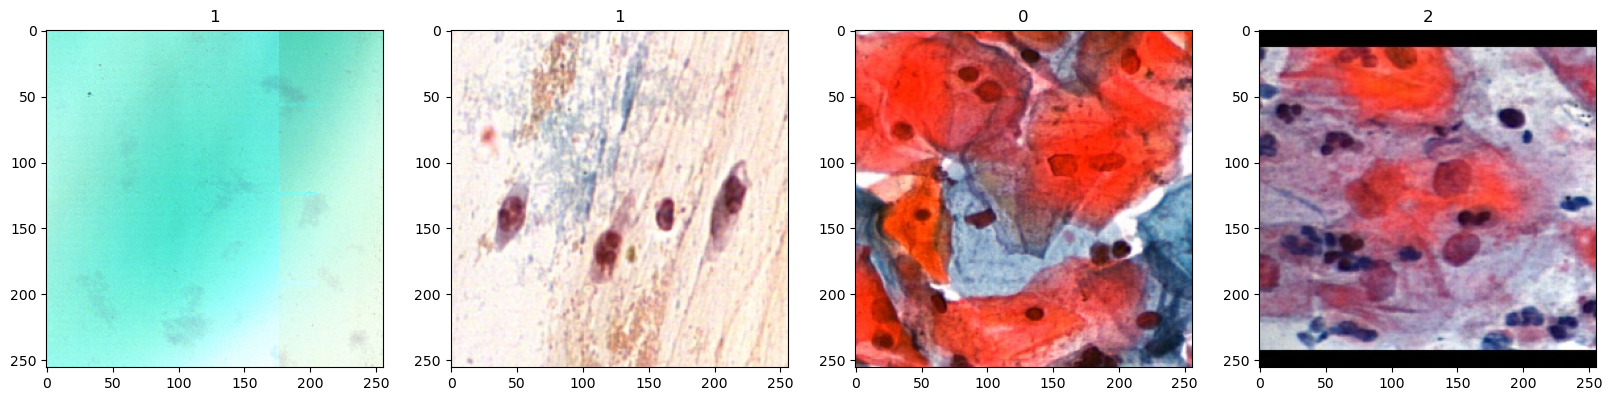

In [183]:
data = tf.keras.utils.image_dataset_from_directory('augmented')
data_iterator = data.as_numpy_iterator()
class_names = data.class_names
batch = data_iterator.next()
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))  
    ax[idx].title.set_text(batch[1][idx]) 

In [185]:
data = tf.keras.utils.image_dataset_from_directory('augmented')
data = data.map(lambda x,y: (x/255, y))
data.as_numpy_iterator().next()[0].max()

Found 19459 files belonging to 3 classes.


1.0

# **SPLIT DATA** 

+ Để train cho model dự đoán chính xác, sẽ chia train: 70% để tránh model bị overfitting

In [191]:
data = data.shuffle(buffer_size=len(data), reshuffle_each_iteration=True)
train_size = int(len(data)*.7)
val_size = int(len(data)*.2)
test_size = int(len(data)*.1)

In [193]:
train_size

426

In [195]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size+val_size).take(test_size)

In [197]:
train

<_TakeDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

## **2.BUILD MODEL VÀ TRAIN**
+ sử dụng BatchNormalization() để chuẩn hoá các layers, giúp model ổn định và train nhanh hơn
+ Sử dụng nhiều layers để tăng độ chính xác cho model

In [199]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization
import tensorflow as tf

In [201]:
model=Sequential()
model.add(Conv2D(16, (3,3), 1, activation='relu', input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D())
model.add(Conv2D(32, (3,3), 1, activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D())
model.add(Conv2D(16, (3,3), 1, activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D())
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(3, activation='softmax'))
model.compile('adam',loss=tf.losses.SparseCategoricalCrossentropy(), metrics=['accuracy'])
model.summary()

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 254, 254, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 254, 254, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 127, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 125, 125, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 125, 125, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 60, 60, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 60, 60, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     3,686,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,729,907 (14.23 MB)

 Trainable params: 3,729,779 (14.23 MB)

 Non-trainable params: 128 (512.00 B)

In [203]:
logdir='logs'

In [205]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)
hist = model.fit(train, epochs=16, validation_data=val, callbacks=[tensorboard_callback])

Epoch 1/16


2025-02-23 17:22:49.937218: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:165226: Filling up shuffle buffer (this may take a while): 587 of 609
2025-02-23 17:22:50.253553: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


426/426 ━━━━━━━━━━━━━━━━━━━━ 168s 365ms/step - accuracy: 0.5586 - loss: 1.3752 - val_accuracy: 0.4595 - val_loss: 1.2902
Epoch 2/16
426/426 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.7027 - loss: 0.7069

2025-02-23 17:28:20.855579: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:165226: Filling up shuffle buffer (this may take a while): 607 of 609
2025-02-23 17:28:20.869147: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


426/426 ━━━━━━━━━━━━━━━━━━━━ 184s 409ms/step - accuracy: 0.7027 - loss: 0.7068 - val_accuracy: 0.7095 - val_loss: 0.6669
Epoch 3/16
426/426 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.7364 - loss: 0.6071

...

426/426 ━━━━━━━━━━━━━━━━━━━━ 186s 413ms/step - accuracy: 0.9764 - loss: 0.0733 - val_accuracy: 0.8915 - val_loss: 0.3662
Epoch 15/16
426/426 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 0.9853 - loss: 0.0501

2025-02-23 18:10:35.877087: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:165226: Filling up shuffle buffer (this may take a while): 585 of 609
2025-02-23 18:10:36.353156: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


426/426 ━━━━━━━━━━━━━━━━━━━━ 185s 411ms/step - accuracy: 0.9853 - loss: 0.0501 - val_accuracy: 0.9137 - val_loss: 0.2936
Epoch 16/16
426/426 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.9869 - loss: 0.0398

2025-02-23 18:13:47.586549: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:165226: Filling up shuffle buffer (this may take a while): 545 of 609
2025-02-23 18:13:48.704043: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


426/426 ━━━━━━━━━━━━━━━━━━━━ 193s 431ms/step - accuracy: 0.9869 - loss: 0.0398 - val_accuracy: 0.8479 - val_loss: 0.5725


# **3. TEST ĐỘ CHÍNH XÁC CỦA MODEL**

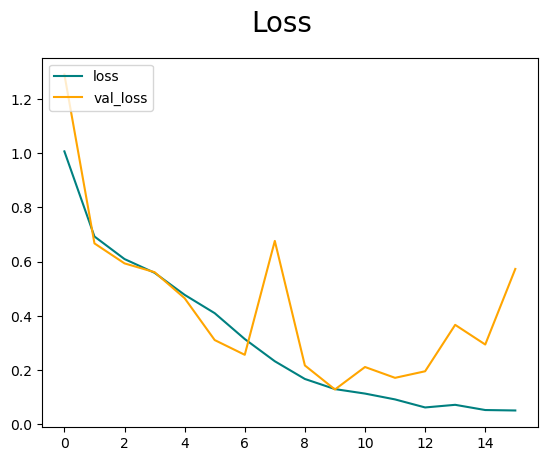

In [207]:
fig = plt.figure()
plt.plot(hist.history['loss'], color='teal', label='loss')
plt.plot(hist.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

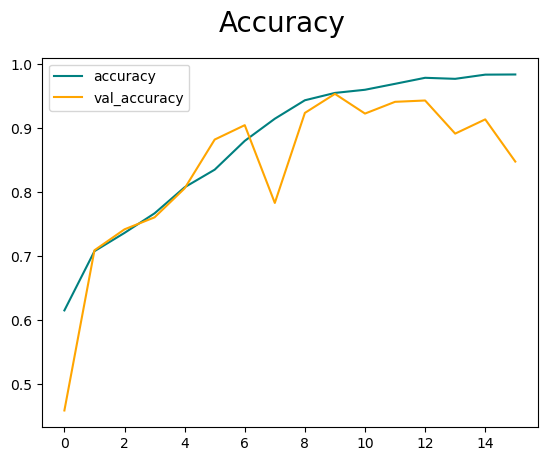

In [209]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color='teal', label='accuracy')
plt.plot(hist.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

In [211]:
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy
import numpy as np

In [213]:
pre = Precision()
re = Recall()
acc = BinaryAccuracy()

In [215]:
print(pre.result(), re.result(), acc.result())

tf.Tensor(0.0, shape=(), dtype=float32) tf.Tensor(0.0, shape=(), dtype=float32) tf.Tensor(0.0, shape=(), dtype=float32)


In [219]:
from tensorflow.keras.models import load_model

**LƯU MODEL:**

In [221]:
model.save('Bacteria.keras')

# **4. DỰ ĐOÁN TỪ FILE TEST**

In [224]:
import pandas as pd
import numpy as np
import os
import cv2
import tensorflow as tf

In [ ]:
res = []
image_files = sorted(os.listdir("private_test"))
for img_name in image_files:
    img_path = os.path.join("private_test", img_name)
    img = cv2.imread(img_path)
    
    if img is None:
        continue  
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_array = tf.image.resize(img, (256, 256))
    img_array = np.expand_dims(img_array/255, axis=0)  
    predictions = model.predict(img_array)
    predicted_class = class_names[np.argmax(predictions)]
    res.append([img_name, predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━

In [227]:
df = pd.DataFrame(res, columns=['image_name', 'label'])
df.to_csv('predictions.csv', index=False)

In [229]:
df = pd.read_csv('predictions.csv')
print(df.head())

       image_name    label
0     image_1.png  healthy
1    image_10.png  rubbish
2   image_100.png  rubbish
3  image_1000.png  healthy
4  image_1001.png  rubbish


In [231]:
import zipfile
with zipfile.ZipFile("prediction.zip", "w", zipfile.ZIP_DEFLATED) as zipf:
    zipf.write("predictions.csv")